In [1]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Madhurjya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Madhurjya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
import pandas as pd

In [3]:
true_df=pd.read_csv("True.csv")
fake_df=pd.read_csv("Fake.csv")
true_df['label']='REAL'
fake_df['label']='FAKE'
print("real news sample: ", len(true_df))
print("fake news samples: ", len(fake_df))

real news sample:  21417
fake news samples:  23481


Joining the 2 datasets together and mixing them up

In [4]:
real_sample=true_df.sample(n=2000, random_state=42)
fake_sample=fake_df.sample(n=2000, random_state=42)

reduced_df=(
    pd.concat([real_sample, fake_sample]).sample(frac=1, random_state=42).reset_index(drop=True)
)
print(reduced_df['label'].value_counts())
print(reduced_df.head())

label
REAL    2000
FAKE    2000
Name: count, dtype: int64
                                               title  \
0  May's government pushes Brexit bill to avoid '...   
1   Trump’s EPA OKs Pesticide That Causes Brain D...   
2  Man arrested at Trump rally said he wanted to ...   
3  Jared Kushner NEVER Registered To Vote As A “F...   
4  MARTHA STEWART Makes Lewd Gesture Towards Trum...   

                                                text       subject  \
0  LONDON (Reuters) - Brexit minister David Davis...     worldnews   
1  Farmworkers were pulled from fields on Friday ...          News   
2  (Reuters) - A man arrested over the weekend tr...  politicsNews   
3  Meanwhile, as President Trump continues to mee...     left-news   
4  Martha, Martha, Martha You re 75-years old! Ti...     left-news   

                 date label  
0  September 6, 2017   REAL  
1        May 15, 2017  FAKE  
2      June 20, 2016   REAL  
3        Sep 29, 2017  FAKE  
4         May 8, 2017  FAKE  


Making it so that only relevant details are kept like the title and text joining it with the label fake and true

In [5]:
reduced_df['content']=reduced_df['title']+ " "+reduced_df['text']
reduced_df=reduced_df[['content', 'label']]
reduced_df.head()

,content,label
0,May's government pushes Brexit bill to avoid '...,REAL
1,Trump’s EPA OKs Pesticide That Causes Brain D...,FAKE
2,Man arrested at Trump rally said he wanted to ...,REAL
3,Jared Kushner NEVER Registered To Vote As A “F...,FAKE
4,MARTHA STEWART Makes Lewd Gesture Towards Trum...,FAKE


In [6]:
import re
import nltk
nltk.download ('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Madhurjya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
stop_words=set(stopwords.words('english'))
def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^a-z\s]', '', text)
    words=text.split()
    words=[w for w in words if w not in stop_words]
    return " ".join(words)
reduced_df['clean_text']=reduced_df['content'].apply(clean_text)
print("Before:\n", reduced_df['content'][0])
print("\nAfter:\n", reduced_df['clean_text'][0])

Before:
 May's government pushes Brexit bill to avoid 'chaotic' departure LONDON (Reuters) - Brexit minister David Davis called on parliament on Thursday to back legislation to sever Britain s political, financial and legal ties with the European Union, saying that opposing the bill would lead to chaos. At a rowdy session of parliament, Davis accused the opposition Labour Party of pursuing a  cynical and unprincipled  path by challenging the repeal bill, or EU withdrawal bill, designed to disentangle Britain from more than 40 years of EU lawmaking. Labour, in turn, said the government was using the bill to give itself wide-ranging powers and a  blank cheque  to do away with laws if ministers did not like them, threatening the rights of ordinary Britons. The legislation is a vital stepping-stone towards Britain s departure from the EU in March 2019. It faces stormy debate and a likely barrage of attempted amendments as Prime Minister Theresa May, weakened by the loss of her majority in 

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer=TfidfVectorizer(max_features=500)

X=vectorizer.fit_transform(reduced_df['clean_text'])
y=reduced_df['label']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9625

Classification Report:
               precision    recall  f1-score   support

        FAKE       0.98      0.95      0.96       402
        REAL       0.95      0.98      0.96       398

    accuracy                           0.96       800
   macro avg       0.96      0.96      0.96       800
weighted avg       0.96      0.96      0.96       800



In [12]:
reduced_df.to_csv("logistic_reduced_news.csv", index=False)

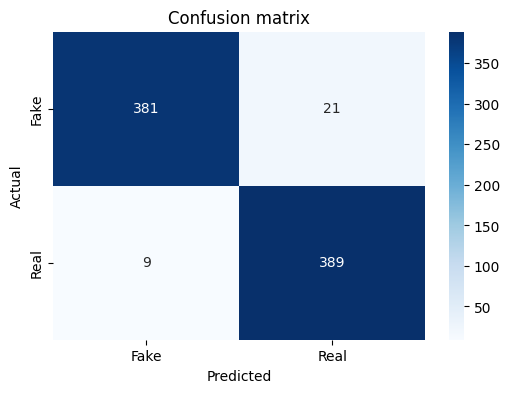

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm ,annot=True, fmt="d", cmap="Blues", xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

In [14]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print("training data: ", train_accuracy)
print("testing data: ", test_accuracy)

training data:  0.975
testing data:  0.9625


In [15]:
import joblib

# Save trained Logistic Regression model
joblib.dump(model, "logistic_fake_news.pkl")

# Save TF-IDF vectorizer (very important)
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Logistic Regression model and vectorizer saved successfully!")

Logistic Regression model and vectorizer saved successfully!
